In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.0MB/s]


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 400),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + epsilon * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

In [ ]:
def loss_function(recon_x, x, mu, logvar):

    # Reconstruction loss
    BCE = nn.functional.binary_cross_entropy(
        recon_x, x.view(-1, 28*28), reduction='sum'
    )

    # KL divergence
    KLD = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KLD

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 15

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)

        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()

        train_loss += loss.item()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {train_loss/len(train_loader.dataset):.4f}")

Epoch 1, Loss: 286.2337
Epoch 2, Loss: 256.0867
Epoch 3, Loss: 250.2819
Epoch 4, Loss: 247.5038
Epoch 5, Loss: 245.9037
Epoch 6, Loss: 244.8444
Epoch 7, Loss: 244.0498
Epoch 8, Loss: 243.4740
Epoch 9, Loss: 242.9781
Epoch 10, Loss: 242.5469
Epoch 11, Loss: 242.1616
Epoch 12, Loss: 241.8117
Epoch 13, Loss: 241.6037
Epoch 14, Loss: 241.3543
Epoch 15, Loss: 241.1695


In [ ]:
model.eval()

VAE(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=400, bias=True)
    (2): ReLU()
  )
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

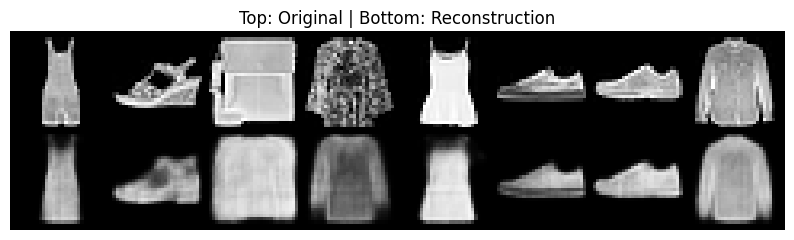

In [ ]:
data, _ = next(iter(train_loader))
data = data.to(device)

recon, _, _ = model(data)

comparison = torch.cat([data[:8],
                        recon.view(-1,1,28,28)[:8]])

grid = torchvision.utils.make_grid(comparison.cpu(), nrow=8)

plt.figure(figsize=(10,4))
plt.imshow(grid.permute(1,2,0))
plt.axis('off')
plt.title("Top: Original | Bottom: Reconstruction")
plt.show()

#ikkada kinda unnadhi exam ki akkarle babu

In [ ]:
from sklearn.decomposition import PCA

model.eval()
zs = []
labels = []

with torch.no_grad():
    for data, label in train_loader:
        data = data.to(device)
        mu, _ = model.encode(data)
        zs.append(mu.cpu())
        labels.append(label)

zs = torch.cat(zs)
labels = torch.cat(labels)

In [ ]:
pca = PCA(n_components=2)
zs_2d = pca.fit_transform(zs)

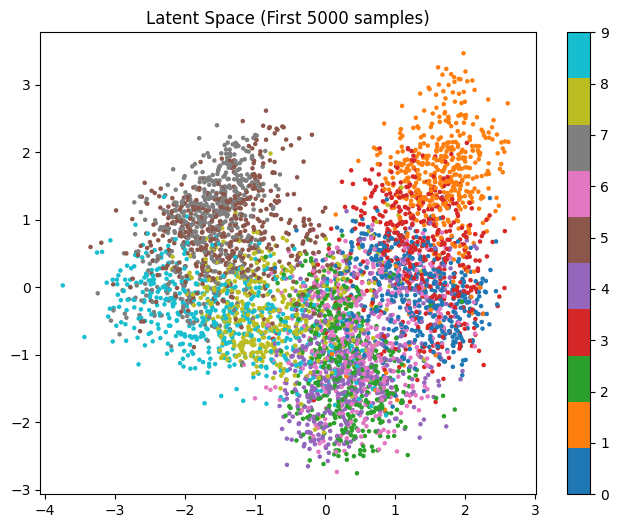

In [ ]:
zs_subset = zs[:5000]
labels_subset = labels[:5000]

pca = PCA(n_components=2)
zs_2d = pca.fit_transform(zs_subset)

plt.figure(figsize=(8,6))
plt.scatter(zs_2d[:,0], zs_2d[:,1],
            c=labels_subset, cmap='tab10', s=5)

plt.colorbar()
plt.title("Latent Space (First 5000 samples)")
plt.show()